# LU decomposition

Factor $A = PLU$ where:

| Matrix | Shape | Structure |
|--------|-------|-----------|
| $P$ | $n \times n$ | permutation (row pivoting) |
| $L$ | $n \times n$ | lower triangular, 1s on diagonal |
| $U$ | $n \times n$ | upper triangular |

Once factored, solve $Ax = b$ in two cheap triangular solves:
1. $Ly = Pb$ (forward substitution)
2. $Ux = y$ (backward substitution)

Cost: $\frac{2}{3}n^3$ for factorization, $2n^2$ per solve. Factor once, solve many.

In [1]:
import os
import sys

if "COLAB_GPU" in os.environ:
    os.system("git clone https://github.com/PritRaj1/tensor_inv.git 2>/dev/null")
    sys.path.insert(0, "/content/tensor_inv/src")
else:
    src = "src" if os.path.isdir("src") else "../src"
    sys.path.insert(0, src)

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

## Gaussian elimination

Row-reduce $A$ into upper triangular $U$. Convert linear system to equations that are analytically easy to solve. Save each multiplier $l_{ik} = a_{ik}/a_{kk}$ in $L$.

For column $k$:
1. Find pivot (largest entry in column for stability)
2. For each row $i > k$: compute multiplier $l_{ik} = a_{ik} / a_{kk}$
3. Subtract: $\text{row}_i \leftarrow \text{row}_i - l_{ik} \cdot \text{row}_k$

After all columns: $A$ has become $U$, multipliers form $L$.

In [3]:
A = torch.tensor(
    [[2.0, 1.0, 1.0], [4.0, 3.0, 3.0], [8.0, 7.0, 9.0]], dtype=torch.float64
)
print("A =")
print(A)

# manual elimination
M = A.clone()
L = torch.eye(3, dtype=torch.float64)

# column 0: eliminate rows 1, 2
for i in [1, 2]:
    L[i, 0] = M[i, 0] / M[0, 0]
    M[i] -= L[i, 0] * M[0]
    print(f"\nstep: row {i} -= {L[i, 0]:.0f} * row 0")
    print(M)

# column 1: eliminate row 2
L[2, 1] = M[2, 1] / M[1, 1]
M[2] -= L[2, 1] * M[1]
print(f"\nstep: row 2 -= {L[2, 1]:.0f} * row 1")
print(M)

U = M
print(f"\nL =\n{L}")
print(f"\nU =\n{U}")
print(f"\n||LU - A|| = {(L @ U - A).abs().max():.1e}")

A =
tensor([[2., 1., 1.],
        [4., 3., 3.],
        [8., 7., 9.]], dtype=torch.float64)

step: row 1 -= 2 * row 0
tensor([[2., 1., 1.],
        [0., 1., 1.],
        [8., 7., 9.]], dtype=torch.float64)

step: row 2 -= 4 * row 0
tensor([[2., 1., 1.],
        [0., 1., 1.],
        [0., 3., 5.]], dtype=torch.float64)

step: row 2 -= 3 * row 1
tensor([[2., 1., 1.],
        [0., 1., 1.],
        [0., 0., 2.]], dtype=torch.float64)

L =
tensor([[1., 0., 0.],
        [2., 1., 0.],
        [4., 3., 1.]], dtype=torch.float64)

U =
tensor([[2., 1., 1.],
        [0., 1., 1.],
        [0., 0., 2.]], dtype=torch.float64)

||LU - A|| = 0.0e+00


## Forward and backward substitution

Given $LU x = b$:

**Forward sub** ($Ly = b$): solve top to bottom. Each $y_i$ depends only on previous $y$'s.

$y_i = b_i - \sum_{j < i} L_{ij} y_j$

**Backward sub** ($Ux = y$): solve bottom to top.

$x_i = \frac{1}{U_{ii}} \left( y_i - \sum_{j > i} U_{ij} x_j \right)$

Both $O(n^2)$. The expensive part was $O(n^3)$ factorization.

In [4]:
b = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64)

# forward sub: Ly = b
y = torch.zeros(3, dtype=torch.float64)
for i in range(3):
    y[i] = b[i] - L[i, :i] @ y[:i]
print(f"forward sub:  y = {y.tolist()}")

# backward sub: Ux = y
x = torch.zeros(3, dtype=torch.float64)
for i in reversed(range(3)):
    x[i] = (y[i] - U[i, i + 1 :] @ x[i + 1 :]) / U[i, i]
print(f"backward sub: x = {x.tolist()}")
print(f"residual ||Ax - b|| = {(A @ x - b).norm():.1e}")

forward sub:  y = [1.0, 0.0, -1.0]
backward sub: x = [0.5, 0.5, -0.5]
residual ||Ax - b|| = 0.0e+00


## Blocked LU + CRT

```
for each block column j:
    panel LU with pivoting        small, unblocked
    triangular solve for U row    panel
    W[j+b:, j+b:] -= L @ U       trailing GEMM  <- CRT
```

~90% is the trailing GEMM.

In [5]:
from tensor_inv import lu as crt_lu

torch.manual_seed(0)
n = 256
A = torch.randn(n, n, dtype=torch.float64)

P_crt, L_crt, U_crt = crt_lu(A, block_size=64)
P_ref, L_ref, U_ref = torch.linalg.lu(A)

err_crt = (P_crt @ A - L_crt @ U_crt).abs().max().item()
err_ref = (P_ref @ L_ref @ U_ref - A).abs().max().item()

print(f"||PA - LU|| CRT blocked: {err_crt:.3e}")
print(f"||PLU - A|| torch:       {err_ref:.3e}")

||PA - LU|| CRT blocked: 2.398e-14
||PLU - A|| torch:       1.776e-14


## Heat conduction

2D steady-state heat equation on unit square, zero boundary:

$-\nabla^2 T = f$

### Discretization

On an $n \times n$ grid with spacing $h = 1/(n+1)$. Approximate $\nabla^2$ with 5-point stencil:

```
        -1
    -1   4  -1
        -1
```

Each interior point $(i,j)$ gives one equation:

$4T_{i,j} - T_{i-1,j} - T_{i+1,j} - T_{i,j-1} - T_{i,j+1} = h^2 f_{i,j}$

### Building $A$

Flatten the 2D grid to 1D index: $\text{idx} = i \cdot n + j$. Each row of $A$ has:
- diagonal entry $A[\text{idx}, \text{idx}] = 4$ (center point)
- off-diagonals $= -1$ for each neighbor that exists
- boundary points have fewer neighbors (Dirichlet BC = 0)

Result: $A$ is $n^2 \times n^2$, sparse, symmetric positive definite.

grid: 32x32, system: 1024x1024
nonzeros: 4992 / 1048576 (0.5% dense)


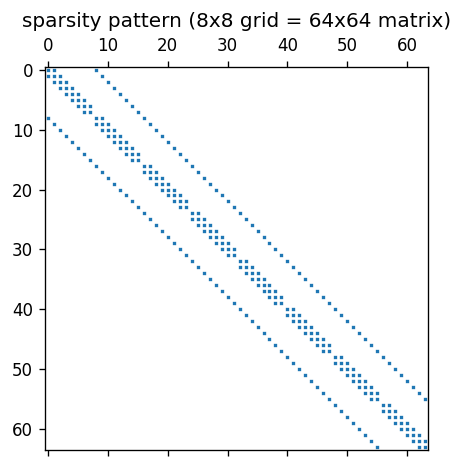

In [6]:
def laplacian_2d(n):
    """5-point stencil Laplacian on n x n grid."""
    N = n * n
    A = torch.zeros(N, N, dtype=torch.float64)
    for i in range(n):
        for j in range(n):
            idx = i * n + j
            A[idx, idx] = 4.0
            if i > 0:
                A[idx, idx - n] = -1.0

            if i < n - 1:
                A[idx, idx + n] = -1.0

            if j > 0:
                A[idx, idx - 1] = -1.0

            if j < n - 1:
                A[idx, idx + 1] = -1.0

    return A


n = 32
h = 1.0 / (n + 1)
A = laplacian_2d(n)
print(f"grid: {n}x{n}, system: {A.shape[0]}x{A.shape[1]}")
print(
    f"nonzeros: {(A != 0).sum().item()} / {A.numel()} ({(A != 0).float().mean():.1%} dense)"
)

# sparsity pattern
A_small = laplacian_2d(8)
fig, ax = plt.subplots(figsize=(4, 4))
ax.spy(A_small.numpy(), markersize=1)
ax.set_title(f"sparsity pattern (8x8 grid = {64}x{64} matrix)")
plt.tight_layout()
plt.show()

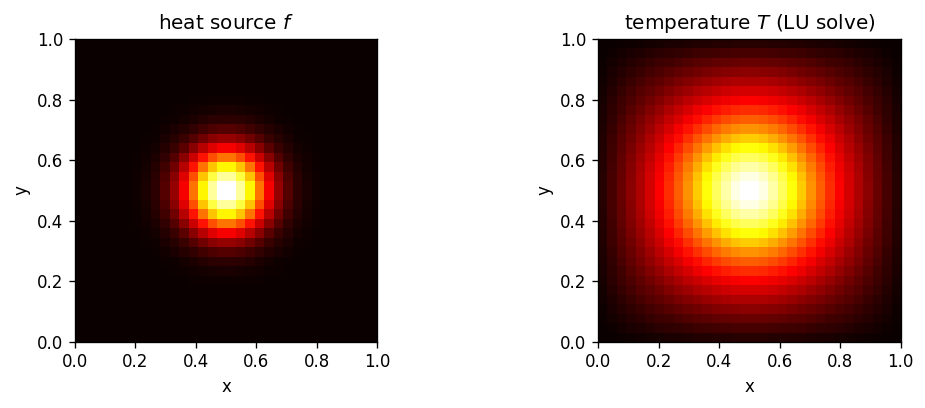

In [7]:
# heat source: hot spot in center
xs = torch.linspace(0, 1, n)
ys = torch.linspace(0, 1, n)
X, Y = torch.meshgrid(xs, ys, indexing="ij")
f = torch.exp(-50 * ((X - 0.5) ** 2 + (Y - 0.5) ** 2))
b = (h**2 * f).reshape(-1).to(torch.float64)

# solve via LU
T = torch.linalg.solve(A, b).reshape(n, n)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(f, extent=[0, 1, 0, 1], origin="lower", cmap="hot")
axes[0].set_title("heat source $f$")
axes[1].imshow(T, extent=[0, 1, 0, 1], origin="lower", cmap="hot")
axes[1].set_title("temperature $T$ (LU solve)")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## CRT accuracy

Compare residual $\|Ax - b\|$ for standard LU vs CRT-based matmul.

In [8]:
from tensor_inv import crt_matmul

x_torch = torch.linalg.solve(A, b)

# residual with standard matmul
r_torch = (A @ x_torch - b).norm()

# residual with CRT matmul
r_crt = (crt_matmul(A, x_torch.unsqueeze(1)).squeeze(1) - b).norm()

print(f"||Ax - b|| torch matmul: {r_torch:.3e}")
print(f"||Ax - b|| CRT matmul:   {r_crt:.3e}")

||Ax - b|| torch matmul: 1.084e-16
||Ax - b|| CRT matmul:   1.282e-16


## Condition number

$\kappa(A) = \|A\| \cdot \|A^{-1}\|$. Large $\kappa$ = small perturbations in $b$ cause large changes in $x$. This is where high-precision GEMM matters a lot.

In [9]:
# ill-conditioned system: Hilbert matrix
sizes = [4, 8, 12, 16]
print(f"{'n':>4} {'cond(A)':>12} {'torch res':>12} {'CRT res':>12}")
print("-" * 44)

for n in sizes:
    H = torch.zeros(n, n, dtype=torch.float64)
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)

    b = H.sum(dim=1)  # x = [1, 1, ..., 1]
    x = torch.linalg.solve(H, b)

    r_torch = (H @ x - b).norm().item()
    r_crt = (crt_matmul(H, x.unsqueeze(1)).squeeze(1) - b).norm().item()
    kappa = torch.linalg.cond(H).item()

    print(f"{n:>4} {kappa:>12.2e} {r_torch:>12.3e} {r_crt:>12.3e}")

   n      cond(A)    torch res      CRT res
--------------------------------------------
   4     1.55e+04    0.000e+00    2.719e-16
   8     1.53e+10    5.661e-16    5.439e-16
  12     1.63e+16    1.041e-15    6.753e-16
  16     8.53e+17    1.522e-15    1.490e-15
